# Mastercard Hidden Business Detection project
(When starting the code make sure all 3 parquet files are in the same folder where file is)

## Dependencies

Install the project dependencies before running the notebook.

```text
polars>=1.0.0
pandas>=2.2.0
numpy>=1.26.0,<2.0.0
scikit-learn>=1.5.0
lightgbm>=4.3.0
catboost>=1.2.5
matplotlib>=3.8.0
seaborn>=0.13.0
joblib>=1.4.0
```

## Implementation all libs

In [12]:
%matplotlib inline

from __future__ import annotations

import json
import warnings
from pathlib import Path

import joblib
import numpy as np
import pandas as pd
import polars as pl
import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import display
from sklearn.base import BaseEstimator, TransformerMixin, clone
from sklearn.ensemble import IsolationForest
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    average_precision_score,
    confusion_matrix,
    f1_score,
    precision_recall_curve,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve,
)
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import RobustScaler
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier

warnings.filterwarnings("ignore", category=UserWarning, module="sklearn")

## Configuration

This block defines all file paths, model thresholds, random seeds, and feature lists used by the pipeline. Keeping these values in one place makes the run reproducible and makes it easy for reviewers to understand which raw files and output folders are expected.

In [13]:
# Notebook-friendly project root. Run this notebook from the repository root.
from pathlib import Path

# Put all raw data in the same folder as this ipynb file
PROJECT_ROOT = Path().resolve()

RAW_DATA_DIR       = PROJECT_ROOT
PROCESSED_DATA_DIR = PROJECT_ROOT / "data" / "processed"
OUTPUTS_DIR        = PROJECT_ROOT / "outputs"
FIGURES_DIR        = OUTPUTS_DIR / "figures"
METRICS_DIR        = OUTPUTS_DIR / "metrics"
MODELS_DIR         = OUTPUTS_DIR / "models"
PREDICTIONS_DIR    = OUTPUTS_DIR / "predictions"

BUSINESS_CARDS_FILE      = RAW_DATA_DIR / "business_cards_MDQ.parquet"
CONSUMER_CARDS_FILE      = RAW_DATA_DIR / "consumer_cards_MDQ.parquet"
MERCHANTS_REFERENCE_FILE = RAW_DATA_DIR / "merchants_reference.parquet"
REQUIRED_RAW_FILES = [
    BUSINESS_CARDS_FILE,
    CONSUMER_CARDS_FILE,
    MERCHANTS_REFERENCE_FILE,
]
OUTPUT_DIRS = [
    PROCESSED_DATA_DIR,
    FIGURES_DIR,
    METRICS_DIR,
    MODELS_DIR,
    PREDICTIONS_DIR,
]

CARD_ID_COLUMN = "card_number"
TARGET_COLUMN = "label"
RANDOM_STATE = 42

TUNE_CV_SPLITS = 3
TUNE_N_ITER = 6
EVAL_CV_SPLITS = 5

GREY_ZONE_LOW = 0.30
GREY_ZONE_HIGH = 0.70
CONF_BIZ_THRESH = 0.80

PI2 = 6.283185307179586
SMALL_AMOUNT = 2_000.0
LARGE_AMOUNT = 50_000.0

SUSPICIOUS_MCCS = [
    "7311", "5968", "5099", "5172", "4816",
    "5912", "5045", "5065", "5094",
]

GREY_ZONE_FEATURES = [
    "hour_mean",
    "commercial_hours_ratio",
    "burst_cv",
    "weekend_ratio",
    "same_merchant_ratio",
    "txns_per_merchant",
    "merchant_diversity",
    "merchants_per_mcc",
    "mcc_diversity",
    "recur_ratio",
    "max_same_amt_count",
    "amt_cv",
    "biz_distance_score",
]

## Plot Theme And Output Helpers

Functions for plotting graphs using Mastercard style

In [14]:
# Identifying the colors
BG = "#0D0D0D"
FG = "#FFFFFF"
MC_RED = "#EB001B"
MC_ORANGE = "#FF5F00"
MC_YELLOW = "#F79E1B"
MC_GOLD = "#FFD700"
GRID_COL = "#2A2A2A"
PALETTE = [MC_RED, MC_ORANGE, MC_YELLOW, MC_GOLD, "#FF8C00", "#DC143C"]

# Changing graphs according to our colors
plt.rcParams.update({
    "figure.facecolor": BG,
    "axes.facecolor": BG,
    "axes.edgecolor": FG,
    "axes.labelcolor": FG,
    "axes.titlecolor": FG,
    "xtick.color": FG,
    "ytick.color": FG,
    "text.color": FG,
    "legend.facecolor": "#1A1A1A",
    "legend.edgecolor": MC_ORANGE,
    "legend.labelcolor": FG,
    "grid.color": GRID_COL,
    "grid.linestyle": "--",
    "grid.alpha": 0.4,
    "font.family": "DejaVu Sans",
    "savefig.facecolor": BG,
    "savefig.edgecolor": "none",
})

SHOW_PLOTS_IN_NOTEBOOK = True


def save_and_show(fig, path: Path, dpi: int = 160) -> None:
    """Save a Matplotlib figure and display it inline."""
    path.parent.mkdir(parents=True, exist_ok=True)
    fig.savefig(path, dpi=dpi)
    if SHOW_PLOTS_IN_NOTEBOOK:
        display(fig)
    plt.close(fig)


def ensure_directories() -> None:
    """Create all output directories required by the pipeline."""
    for directory in OUTPUT_DIRS:
        Path(directory).mkdir(parents=True, exist_ok=True)


def save_json(obj, path: Path) -> None:
    """Write a JSON file using readable indentation and string fallback."""
    path.parent.mkdir(parents=True, exist_ok=True)
    with path.open("w", encoding="utf-8") as file:
        json.dump(obj, file, ensure_ascii=False, indent=2, default=str)

## Loading And Preprocessing

This section loads the three required parquet files and normalizes column names across possible schema variants. It also enriches transactions with merchant reference data and creates transaction-level flags such as online activity, recurring payments, night transactions, and suspicious MCC categories.

In [15]:
def load_raw_data() -> dict[str, pl.DataFrame]:
    """Load the three required parquet files and fail early if any are missing."""
    for path in REQUIRED_RAW_FILES:
        if not path.exists():
            raise FileNotFoundError(f"Missing data file: {path}")
    return {
        "business_cards":      pl.read_parquet(BUSINESS_CARDS_FILE),
        "consumer_cards":      pl.read_parquet(CONSUMER_CARDS_FILE),
        "merchants_reference": pl.read_parquet(MERCHANTS_REFERENCE_FILE),
    }


def _coalesce(df: pl.DataFrame, candidates: list[str], alias: str) -> pl.Expr:
    """Pick the first available column from candidates — handles inconsistent raw schemas."""
    columns = [pl.col(column) for column in candidates if column in df.columns]
    return (pl.coalesce(columns) if columns else pl.lit(None)).alias(alias)


def prepare_transactions(
    df: pl.DataFrame,
    merchants: pl.DataFrame | None,
    source_name: str,
) -> pl.DataFrame:
    """Normalize raw transaction columns and enrich with merchant reference data."""

    # Different raw files use different names for the same field — unify them all
    df = df.with_columns([
        _coalesce(df, [CARD_ID_COLUMN, "card_id", "pan"],                          CARD_ID_COLUMN).cast(pl.Utf8),
        _coalesce(df, ["transaction_amount_kzt", "amount_kzt", "amount",
                        "transaction_amount"],                                       "amount").cast(pl.Float64, strict=False),
        _coalesce(df, ["mcc", "merchant_mcc"],                                      "mcc").cast(pl.Utf8),
        _coalesce(df, ["merchant_id", "merchant"],                                  "merchant_id").cast(pl.Utf8),
        _coalesce(df, ["channel", "entry_mode"],                                    "channel").cast(pl.Utf8),
        _coalesce(df, ["tokenized", "is_tokenized"],                                "tokenized").cast(pl.Boolean, strict=False),
        _coalesce(df, ["recurring", "is_recurring"],                                "recurring").cast(pl.Boolean, strict=False),
        _coalesce(df, ["country", "merchant_country", "country_code"],              "country").cast(pl.Utf8),
        _coalesce(df, ["card_tier", "product_segment", "segment"],                  "card_tier").cast(pl.Utf8),
        _coalesce(df, ["transaction_datetime", "transaction_timestamp",
                        "timestamp", "transaction_date"],                           "ts_raw").cast(pl.Utf8),
    ])

    if merchants is not None and "merchant_id" in merchants.columns:
        merchant_ref = merchants

        # Normalize reference table column names before joining
        if "mcc" not in merchant_ref.columns and "merchant_mcc" in merchant_ref.columns:
            merchant_ref = merchant_ref.rename({"merchant_mcc": "mcc"})
        if "country" not in merchant_ref.columns:
            for column in ["merchant_country", "country_code"]:
                if column in merchant_ref.columns:
                    merchant_ref = merchant_ref.rename({column: "country"})
                    break

        keep = [c for c in ["merchant_id", "mcc", "country"] if c in merchant_ref.columns]
        merchant_ref = merchant_ref.select(keep).unique("merchant_id")
        df = df.join(merchant_ref, on="merchant_id", how="left", suffix="_ref")

        # Prefer transaction's own value; fill gaps from merchant reference
        for column in ["mcc", "country"]:
            ref_column = f"{column}_ref"
            if ref_column in df.columns:
                df = df.with_columns(
                    pl.coalesce([pl.col(column), pl.col(ref_column)]).alias(column)
                ).drop(ref_column)

    df = df.with_columns(
        pl.col("ts_raw").str.to_datetime(strict=False).alias("dt")
    ).with_columns([
        pl.col("dt").dt.date().alias("date"),
        pl.col("dt").dt.hour().alias("hour"),
        pl.col("dt").dt.weekday().alias("dow"),   # 0=Mon, 6=Sun
        pl.col("channel").str.to_lowercase().fill_null("unknown"),
        pl.col("country").fill_null("UNK"),
        pl.col("card_tier").fill_null("unknown").str.to_lowercase(),
        pl.col("mcc").fill_null("UNK"),
        pl.col("merchant_id").fill_null("UNK"),
        pl.col("tokenized").fill_null(False),
        pl.col("recurring").fill_null(False),
        pl.lit(source_name).alias("source_name"),
    ]).drop("ts_raw")
    return df


def add_txn_flags(df: pl.DataFrame) -> pl.DataFrame:
    """Add behavioral flags per transaction. Aggregated to ratios at card level later."""
    return df.with_columns([
        pl.col("amount").abs().alias("amt_abs"),
        pl.col("amount").abs().log1p().alias("log_amt"),    # log scale softens extreme values

        (pl.col("channel") == "online").cast(pl.Int8).alias("f_online"),
        pl.col("tokenized").cast(pl.Int8, strict=False).fill_null(0).alias("f_token"),
        pl.col("recurring").cast(pl.Int8, strict=False).fill_null(0).alias("f_recur"),

        pl.col("hour").is_between(1, 5).cast(pl.Int8).alias("f_night"),
        (pl.col("dow") >= 6).cast(pl.Int8).alias("f_weekend"),

        (pl.col("amount").abs() <= SMALL_AMOUNT).cast(pl.Int8).alias("f_small"),
        (pl.col("amount").abs() >= LARGE_AMOUNT).cast(pl.Int8).alias("f_large"),

        pl.col("mcc").is_in(SUSPICIOUS_MCCS).cast(pl.Int8).alias("f_susp_mcc"),

        # Premium cards are disproportionately common among hidden businesses
        pl.col("card_tier").str.contains(
            "premium|affluent|black|platinum|signature|infinite",
            literal=False,
        ).fill_null(False).cast(pl.Int8).alias("f_premium"),

        # Sine/cosine so the model understands that 23:00 and 00:00 are close
        ((PI2 * pl.col("hour") / 24).sin()).alias("hour_sin"),
        ((PI2 * pl.col("hour") / 24).cos()).alias("hour_cos"),

        # Late-night online payments often indicate automated B2B activity
        ((pl.col("channel") == "online") & pl.col("hour").is_between(1, 5))
            .cast(pl.Int8).alias("f_online_night"),
    ])

## Feature Engineering

The feature engineering block converts raw transactions into one row per card. The features capture transaction volume, amount behavior, merchant diversity, MCC concentration, timing patterns, recurring payments, and business-hour rhythm so the model learns behavior rather than memorizing card IDs.

### Feature Engineering: Business Logic

Standard transaction data is insufficient to detect hidden B2B operations. Therefore, aggregated features reflecting commercial behavior patterns were generated during the Feature Engineering stage:

1. **`commercial_hours_ratio`**: Indicates the proportion of transactions made during typical business hours. Regular activity during consistent working hours is characteristic of business cash settlements, unlike chaotic personal spending.
2. **`recur_ratio` (Recurrence Ratio)**: Businesses often have fixed counterparties (e.g., rent payments, purchases from the same suppliers). A high percentage of repeating transactions with identical amounts or MCC codes is a strong signal.
3. **`mcc_diversity` (MCC Code Diversity)**: A typical individual spends money across a wide range of categories (groceries, entertainment, pharmacies). A narrow-profile hidden business usually concentrates spending in 1 to 3 specific MCC codes (e.g., exclusively building materials or wholesale purchases).
4. **Outlier Smoothing (`log_amt`)**: Applying a logarithmic transformation to transaction amounts reduces the impact of extreme values (large one-time purchases), making the distribution more normal for linear models.

In [16]:
def _safe_ratio(num: pl.Expr, den: pl.Expr, alias: str) -> pl.Expr:
    """Division that returns 0 instead of inf/nan when denominator is zero."""
    return pl.when(den > 0).then(num / den).otherwise(0.0).alias(alias)


def aggregate_card_features(tx: pl.DataFrame, label: int | None) -> pl.DataFrame:
    """Aggregate transaction rows into one behavioral feature row per card."""
    drop_cols = [column for column in ["source_name", "dt", "ts_raw"] if column in tx.columns]
    if drop_cols:
        tx = tx.drop(drop_cols)

    # How concentrated is spending at the single most-visited merchant?
    top_merch = (
        tx.group_by([CARD_ID_COLUMN, "merchant_id"])
        .agg(pl.len().alias("cnt"))
        .sort([CARD_ID_COLUMN, "cnt"], descending=[False, True])
        .group_by(CARD_ID_COLUMN)
        .agg(pl.first("cnt").alias("top1_cnt"))
    )

    # How often does the exact same amount repeat? (payroll / B2B pattern)
    per_amt = (
        tx.with_columns(pl.col("amount").round(0).alias("amt_r"))
        .group_by([CARD_ID_COLUMN, "amt_r"])
        .agg(pl.len().alias("cnt"))
    )
    rep = per_amt.group_by(CARD_ID_COLUMN).agg(
        pl.col("cnt").max().fill_null(1).alias("max_same_amt_count")
    )

    # Coefficient of variation of daily transaction counts — spiky = business-like
    daily = tx.group_by([CARD_ID_COLUMN, "date"]).agg(pl.len().alias("d_cnt"))
    burst = (
        daily.group_by(CARD_ID_COLUMN)
        .agg([
            pl.col("d_cnt").mean().fill_null(1).alias("dmean"),
            pl.col("d_cnt").std().fill_null(0).alias("dstd"),
        ])
        .with_columns(_safe_ratio(pl.col("dstd"), pl.col("dmean"), "burst_cv"))
        .drop(["dmean", "dstd"])
    )

    amt_q95 = tx.group_by(CARD_ID_COLUMN).agg(
        pl.col("amt_abs").quantile(0.95).alias("amt_q95")
    )

    # Weekday 9–18 activity ratio: genuine businesses operate on a schedule
    tx = tx.with_columns(
        ((pl.col("dow") < 6) & pl.col("hour").is_between(9, 18))
        .cast(pl.Int8)
        .alias("f_commercial_hours")
    )

    card = tx.group_by(CARD_ID_COLUMN).agg([
        pl.len().alias("n_txns"),
        pl.col("amt_abs").mean().alias("amt_mean"),
        pl.col("amt_abs").std().fill_null(0).alias("amt_std"),
        pl.col("amt_abs").median().alias("amt_median"),
        pl.col("amt_abs").min().alias("amt_min"),
        pl.col("log_amt").std().fill_null(0).alias("log_amt_std"),
        pl.col("merchant_id").n_unique().alias("n_merchants"),
        pl.col("mcc").n_unique().alias("mcc_diversity"),
        pl.col("country").n_unique().alias("n_countries_raw"),
        pl.col("f_online").mean().alias("online_ratio"),
        pl.col("f_token").mean().alias("token_ratio"),
        pl.col("f_recur").mean().alias("recur_ratio"),
        pl.col("f_night").mean().alias("night_ratio"),
        pl.col("f_weekend").mean().alias("weekend_ratio"),
        pl.col("f_susp_mcc").mean().alias("susp_mcc_ratio"),
        pl.col("f_premium").mean().alias("premium_ratio"),
        pl.col("f_online_night").mean().alias("online_night_ratio"),
        pl.col("hour").mean().alias("hour_mean"),
        pl.col("f_commercial_hours").mean().alias("commercial_hours_ratio"),
    ])

    card = card.with_columns([
        _safe_ratio(pl.col("n_merchants"), pl.col("n_txns"),              "merchant_diversity"),
        _safe_ratio(pl.col("n_countries_raw") - 1, pl.col("n_txns"),     "foreign_ratio"),
        _safe_ratio(pl.col("amt_std"), pl.col("amt_mean") + 1e-6,        "amt_cv"),
        _safe_ratio(pl.col("n_txns"), pl.col("n_merchants") + 1e-6,      "txns_per_merchant"),
        _safe_ratio(pl.col("n_merchants"), pl.col("mcc_diversity") + 1e-6, "merchants_per_mcc"),
    ]).drop("n_countries_raw")

    card = (
        card.join(top_merch, on=CARD_ID_COLUMN, how="left")
            .join(rep,       on=CARD_ID_COLUMN, how="left")
            .join(burst,     on=CARD_ID_COLUMN, how="left")
            .join(amt_q95,   on=CARD_ID_COLUMN, how="left")
            .fill_null(0)
    )
    card = card.with_columns(
        _safe_ratio(pl.col("top1_cnt"), pl.col("n_txns"), "same_merchant_ratio")
    ).drop("top1_cnt")

    if label is not None:
        card = card.with_columns(pl.lit(label).alias(TARGET_COLUMN))
    return card.sort(CARD_ID_COLUMN)


def build_dataset_features(
    biz_tx: pl.DataFrame,
    cons_tx: pl.DataFrame,
) -> tuple[pl.DataFrame, pl.DataFrame]:
    """Build labeled card-level features for business and consumer segments."""
    return aggregate_card_features(biz_tx, 1), aggregate_card_features(cons_tx, 0)


def fit_biz_distance_predictor(
    X_train_fold: pd.DataFrame,
    y_train_fold: np.ndarray,
) -> tuple[RobustScaler, np.ndarray, np.ndarray]:
    """Compute business/consumer centroids strictly on the training fold — no leakage."""
    scaler = RobustScaler()
    Xtr_scaled = scaler.fit_transform(X_train_fold)
    biz_centroid = Xtr_scaled[y_train_fold == 1].mean(axis=0)
    con_centroid = Xtr_scaled[y_train_fold == 0].mean(axis=0)
    return scaler, biz_centroid, con_centroid


def compute_biz_distance_score(
    scaler: RobustScaler,
    biz_centroid: np.ndarray,
    con_centroid: np.ndarray,
    X_score: pd.DataFrame,
) -> np.ndarray:
    """Return a [0, 1] score: how much closer is this card to the business centroid?"""
    Xsc = scaler.transform(X_score)
    # Positive diff → closer to biz centroid → higher score after sigmoid
    diff = np.linalg.norm(Xsc - con_centroid, axis=1) - np.linalg.norm(Xsc - biz_centroid, axis=1)
    score = 1.0 / (1.0 + np.exp(-diff / (diff.std() + 1e-6)))
    return score.astype(np.float32)


def compute_isolation_score(
    X_cons_train: pd.DataFrame,
    X_cons_score: pd.DataFrame,
    random_state: int = RANDOM_STATE,
) -> np.ndarray:
    """Anomaly score relative to normal consumer behavior — higher means more business-like."""
    scaler = RobustScaler()
    X_train_scaled = scaler.fit_transform(X_cons_train)
    X_score_scaled = scaler.transform(X_cons_score)

    iso = IsolationForest(
        n_estimators=300,
        contamination=0.05,
        random_state=random_state,
        n_jobs=-1,
    )
    iso.fit(X_train_scaled)

    # decision_function returns negative scores for anomalies — flip and normalize to [0, 1]
    raw = iso.decision_function(X_score_scaled)
    score = -raw
    score = (score - score.min()) / (score.max() - score.min() + 1e-9)
    return score.astype(np.float32)

## Models And Metrics

This section defines the candidate models, hyperparameter search spaces, model selection rule, grey-zone refiner, and evaluation metrics. The base learners are compared with ROC-AUC and F1, while the secondary refiner focuses on ambiguous cards in the grey zone.

### Architecture and Model Selection

An ensemble approach with Out-of-Fold (OOF) validation is used to solve the binary classification task (B2B vs B2C). The following base algorithms were selected:

*   **Logistic Regression (Baseline)**: Used as an interpretable baseline solution. It allows evaluating the linear separability of classes after feature scaling (`RobustScaler`).
*   **LightGBM**: Chosen for its high training speed on large volumes of transactional data and effective handling of dense features. The algorithm is robust to non-linear relationships and does not require strict data normalization.
*   **CatBoost**: The optimal choice for handling categorical features (e.g., MCC codes or terminal types) without the need for complex preprocessing like One-Hot Encoding. Its symmetric decision trees make the model less prone to overfitting on noisy data.

Using `StratifiedKFold` ensures that class balance is preserved in both the training and validation sets, which is critical when detecting rare events (hidden businesses).

In [17]:
class PassThrough(BaseEstimator, TransformerMixin):
    """No-op transformer — keeps LightGBM/CatBoost inside a Pipeline without scaling."""

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        return X


def class_weight_ratio(y: np.ndarray) -> float:
    """How many negatives per positive — passed as scale_pos_weight to tree models."""
    neg = int((y == 0).sum())
    pos = int((y == 1).sum())
    return float(neg / pos) if pos > 0 else 1.0


def build_candidates(random_state: int, spw: float) -> dict[str, Pipeline]:
    """Three base model candidates, all wrapped in a sklearn Pipeline for uniform API."""
    return {
        "lightgbm": Pipeline([
            ("imp",   SimpleImputer(strategy="median")),
            ("sc",    PassThrough()),
            ("model", LGBMClassifier(
                n_estimators=600,
                learning_rate=0.03,
                num_leaves=31,
                min_child_samples=20,
                subsample=0.8,
                colsample_bytree=0.8,
                reg_alpha=0.1,
                reg_lambda=1.0,
                scale_pos_weight=spw,
                random_state=random_state,
                n_jobs=-1,
                verbosity=-1,
            )),
        ]),
        "catboost": Pipeline([
            ("imp",   SimpleImputer(strategy="median")),
            ("sc",    PassThrough()),
            ("model", CatBoostClassifier(
                iterations=400,
                depth=6,
                learning_rate=0.05,
                l2_leaf_reg=5.0,
                min_data_in_leaf=10,
                scale_pos_weight=spw,
                random_seed=random_state,
                verbose=0,
            )),
        ]),
        "logistic_regression": Pipeline([
            ("imp",   SimpleImputer(strategy="median")),
            ("sc",    RobustScaler()),           # LR needs scaling, unlike tree models
            ("model", LogisticRegression(
                max_iter=3000,
                class_weight="balanced",
                C=0.5,
                random_state=random_state,
            )),
        ]),
    }


def param_grids() -> dict[str, dict[str, list]]:
    """Hyperparameter search spaces for RandomizedSearchCV."""
    return {
        "lightgbm": {
            "model__n_estimators":      [400, 600, 800],
            "model__learning_rate":     [0.02, 0.05, 0.08],
            "model__num_leaves":        [15, 31, 63],
            "model__min_child_samples": [10, 20, 40],
            "model__reg_alpha":         [0.0, 0.1, 1.0],
            "model__reg_lambda":        [0.1, 1.0, 5.0],
            "model__colsample_bytree":  [0.6, 0.8, 1.0],
        },
        "catboost": {
            "model__iterations":       [300, 500, 700],
            "model__depth":            [4, 6, 8],
            "model__learning_rate":    [0.02, 0.05, 0.08],
            "model__l2_leaf_reg":      [1, 5, 9],
            "model__min_data_in_leaf": [5, 10, 20],
        },
        "logistic_regression": {
            "model__C":      np.logspace(-3, 1, 8).tolist(),
            "model__solver": ["lbfgs", "liblinear"],
        },
    }


def select_best_model_name(
    metrics_by_model: dict[str, dict[str, float]],
    primary: str = "roc_auc",
    fallback: str = "f1",
) -> str:
    """Pick the model with the highest ROC-AUC, breaking ties with F1."""
    return max(
        metrics_by_model,
        key=lambda name: (
            round(metrics_by_model[name].get(primary) or -1, 4),
            round(metrics_by_model[name].get(fallback) or -1, 4),
        ),
    )


def train_grey_zone_model(
    X_grey: pd.DataFrame,
    y_grey: np.ndarray,
    random_state: int = RANDOM_STATE,
) -> Pipeline:
    """Train the secondary refiner on confident samples from the grey zone.

    Uses a shallower, more regularized LightGBM to avoid overfitting
    on the small confident-sampling dataset.
    """
    spw = class_weight_ratio(y_grey)
    pipe = Pipeline([
        ("imp",   SimpleImputer(strategy="median")),
        ("sc",    RobustScaler()),
        ("model", LGBMClassifier(
            n_estimators=500,
            learning_rate=0.02,
            num_leaves=15,        # shallow trees = less overfit on small dataset
            min_child_samples=30,
            subsample=0.8,
            colsample_bytree=0.7,
            reg_alpha=0.5,
            reg_lambda=5.0,
            scale_pos_weight=spw,
            random_state=random_state,
            n_jobs=-1,
            verbosity=-1,
        )),
    ])
    pipe.fit(X_grey, y_grey)
    return pipe


def calculate_metrics(
    y_true: np.ndarray,
    y_pred: np.ndarray,
    y_score: np.ndarray,
) -> dict[str, float | None]:
    """Standard classification metrics. ROC-AUC and Avg-Precision require both classes."""
    has_both = len(np.unique(y_true)) > 1
    return {
        "roc_auc":           float(roc_auc_score(y_true, y_score))           if has_both else None,
        "average_precision": float(average_precision_score(y_true, y_score)) if has_both else None,
        "f1":        float(f1_score(y_true, y_pred, zero_division=0)),
        "precision": float(precision_score(y_true, y_pred, zero_division=0)),
        "recall":    float(recall_score(y_true, y_pred, zero_division=0)),
        "accuracy":  float(accuracy_score(y_true, y_pred)),
    }


def make_curve_payloads(
    y_true: np.ndarray,
    proba_by_model: dict[str, np.ndarray],
) -> tuple[dict, dict]:
    """Prepare ROC and precision-recall curve data for all models at once."""
    roc_data, pr_data = {}, {}
    for name, probs in proba_by_model.items():
        fpr, tpr, _         = roc_curve(y_true, probs)
        precision, recall, _ = precision_recall_curve(y_true, probs)
        roc_data[name] = {"fpr": fpr, "tpr": tpr,
                          "auc": float(roc_auc_score(y_true, probs))}
        pr_data[name]  = {"precision": precision, "recall": recall,
                          "ap": float(average_precision_score(y_true, probs))}
    return roc_data, pr_data

## Diagnostic Plots

These plotting functions create the eight diagnostic figures used for model validation and presentation.

In [18]:
def plot_confusion_matrix(y_true, y_pred, path: Path, title: str) -> None:
    """Save and display the confusion matrix for the selected pipeline."""
    import matplotlib.colors as mcolors

    cm = confusion_matrix(y_true, y_pred)
    cmap = mcolors.LinearSegmentedColormap.from_list(
        "mc", ["#1a0000", MC_RED, MC_ORANGE, MC_YELLOW]
    )
    fig, ax = plt.subplots(figsize=(6, 5))
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap=cmap,
        ax=ax,
        xticklabels=["Consumer", "Business"],
        yticklabels=["Consumer", "Business"],
        linecolor=BG,
        linewidths=0.5,
        annot_kws={"color": FG, "fontweight": "bold"},
    )
    ax.set_title(title, color=MC_YELLOW, fontweight="bold")
    ax.set_xlabel("Predicted", color=FG)
    ax.set_ylabel("Actual", color=FG)
    plt.tight_layout()
    save_and_show(fig, path)


def plot_score_distribution(
    scores_dict: dict[str, np.ndarray],
    path: Path,
    title: str,
    log_scale: bool = True,
) -> None:
    """Save and display score distributions for business and consumer cards."""
    colors = [MC_RED, MC_ORANGE, MC_YELLOW, MC_GOLD]
    fig, ax = plt.subplots(figsize=(10, 5))
    for (label, scores), color in zip(scores_dict.items(), colors):
        ax.hist(
            scores,
            bins=60,
            alpha=0.75,
            label=label,
            color=color,
            log=log_scale,
            density=True,
        )
    ax.set_title(title, color=MC_YELLOW, fontweight="bold")
    ax.set_xlabel("Score")
    ax.legend()
    ax.grid(axis="y")
    plt.tight_layout()
    save_and_show(fig, path)


def plot_roc_curves(roc_data: dict, path: Path) -> None:
    """Save and display ROC curves for model score payloads."""
    colors = [MC_RED, MC_ORANGE, MC_YELLOW, MC_GOLD]
    fig, ax = plt.subplots(figsize=(7, 6))
    for (name, payload), color in zip(roc_data.items(), colors):
        ax.plot(
            payload["fpr"],
            payload["tpr"],
            color=color,
            lw=2,
            label=f"{name}  AUC={payload['auc']:.4f}",
        )
    ax.plot([0, 1], [0, 1], "--", color="#444444", lw=1)
    ax.set_xlabel("FPR")
    ax.set_ylabel("TPR")
    ax.set_title("ROC Curves — OOF", color=MC_YELLOW, fontweight="bold")
    ax.legend()
    ax.grid()
    plt.tight_layout()
    save_and_show(fig, path)


def plot_precision_recall_curves(pr_data: dict, path: Path) -> None:
    """Save and display precision-recall curves for model score payloads."""
    colors = [MC_RED, MC_ORANGE, MC_YELLOW, MC_GOLD]
    fig, ax = plt.subplots(figsize=(7, 6))
    for (name, payload), color in zip(pr_data.items(), colors):
        ax.plot(
            payload["recall"],
            payload["precision"],
            color=color,
            lw=2,
            label=f"{name}  AP={payload['ap']:.4f}",
        )
    ax.set_xlabel("Recall")
    ax.set_ylabel("Precision")
    ax.set_title("Precision-Recall Curves — OOF", color=MC_YELLOW, fontweight="bold")
    ax.legend()
    ax.grid()
    plt.tight_layout()
    save_and_show(fig, path)


def plot_feature_importance(fi: pd.DataFrame, path: Path, top_n: int = 25) -> None:
    """Save and display the top model feature importances."""
    import matplotlib.colors as mcolors

    fi = fi.sort_values("importance", ascending=False).head(top_n)
    cmap = mcolors.LinearSegmentedColormap.from_list("mc_bar", [MC_RED, MC_ORANGE, MC_YELLOW])
    colors = cmap(np.linspace(0, 1, len(fi)))
    fig, ax = plt.subplots(figsize=(10, max(5, top_n * 0.30)))
    ax.barh(fi["feature"], fi["importance"], color=colors)
    ax.invert_yaxis()
    ax.set_title(f"Top-{top_n} Feature Importances", color=MC_YELLOW, fontweight="bold")
    ax.set_xlabel("Importance")
    ax.grid(axis="x")
    plt.tight_layout()
    save_and_show(fig, path)


def plot_grey_zone_analysis(
    ensemble_scores: np.ndarray,
    final_scores: np.ndarray,
    grey_low: float,
    grey_high: float,
    path: Path,
) -> None:
    """Save and display before/after/delta diagnostics for grey-zone cards."""
    mask = (ensemble_scores >= grey_low) & (ensemble_scores <= grey_high)
    before = ensemble_scores[mask]
    after = final_scores[mask]

    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    fig.suptitle(
        f"Grey Zone Refiner Analysis  [{grey_low}, {grey_high}]  n={mask.sum():,}",
        fontsize=13,
        fontweight="bold",
        color=MC_YELLOW,
    )

    axes[0].hist(before, bins=40, color=MC_ORANGE, alpha=0.85)
    axes[0].set_title("Before refiner (ensemble_score)", color=FG)
    axes[0].set_xlabel("Score")
    axes[0].axvline(0.5, color=MC_RED, ls="--", lw=1.5)

    axes[1].hist(after, bins=40, color=MC_RED, alpha=0.85)
    axes[1].set_title("After refiner (final_score)", color=FG)
    axes[1].set_xlabel("Score")
    axes[1].axvline(0.5, color=MC_YELLOW, ls="--", lw=1.5)

    delta = after - before
    axes[2].hist(delta, bins=40, color=MC_GOLD, alpha=0.85)
    axes[2].set_title("Score delta (after - before)", color=FG)
    axes[2].set_xlabel("Delta Score")
    axes[2].axvline(0, color=MC_RED, ls="--", lw=1.5)
    moved_up = int((delta > 0.05).sum())
    moved_down = int((delta < -0.05).sum())
    axes[2].text(
        0.05,
        0.92,
        f"UP   (+0.05): {moved_up:,} cards\nDOWN (-0.05): {moved_down:,} cards",
        transform=axes[2].transAxes,
        fontsize=9,
        va="top",
        bbox=dict(boxstyle="round", facecolor="#1A0000", edgecolor=MC_ORANGE, alpha=0.9),
        color=MC_YELLOW,
    )

    plt.tight_layout()
    save_and_show(fig, path)


def plot_consumer_score_breakdown(
    base_scores: np.ndarray,
    dist_scores: np.ndarray,
    iso_scores: np.ndarray,
    final_scores: np.ndarray,
    path: Path,
) -> None:
    """Save and display histograms for the final score components."""
    fig, axes = plt.subplots(2, 2, figsize=(13, 8))
    fig.suptitle("Consumer Card Score Components", fontsize=14, fontweight="bold", color=MC_YELLOW)
    panels = [
        (base_scores, "Base model P(biz) [diagnostic]", MC_ORANGE),
        (dist_scores, "Distance score (centroid)", MC_RED),
        (iso_scores, "Isolation Forest anomaly", MC_GOLD),
        (final_scores, "Final score (ensemble + grey refiner)", "#FF2244"),
    ]
    for ax, (scores, title, color) in zip(axes.ravel(), panels):
        ax.hist(scores, bins=60, color=color, alpha=0.85, log=True)
        ax.set_title(title, fontsize=10, color=FG)
        ax.set_xlabel("Score")
        p95 = float(np.percentile(scores, 95))
        p99 = float(np.percentile(scores, 99))
        ax.axvline(p95, color=MC_YELLOW, ls="--", lw=1.2, label=f"p95={p95:.3f}")
        ax.axvline(p99, color=FG, ls=":", lw=1.2, label=f"p99={p99:.3f}")
        ax.legend(fontsize=8)
    plt.tight_layout()
    save_and_show(fig, path)


def plot_top_suspicious_cards(
    card_ids: np.ndarray,
    scores: np.ndarray,
    path: Path,
    top_n: int = 50,
) -> None:
    """Save and display a ranked bar chart of the top suspicious consumer cards."""
    df = (
        pd.DataFrame({"card": card_ids, "score": scores})
        .sort_values("score", ascending=False)
        .head(top_n)
    )
    colors = [
        MC_RED if score >= 0.70 else MC_ORANGE if score >= 0.50 else MC_YELLOW
        for score in df["score"]
    ]
    fig, ax = plt.subplots(figsize=(13, max(7, top_n * 0.24)))
    ax.barh(range(len(df)), df["score"], color=colors)
    ax.set_yticks(range(len(df)))
    ax.set_yticklabels([f"...{str(card)[-8:]}" for card in df["card"]], fontsize=7)
    ax.invert_yaxis()
    ax.axvline(0.50, color=MC_YELLOW, ls="--", lw=1.2, label="0.50")
    ax.axvline(0.70, color=MC_RED, ls=":", lw=1.5, label="0.70 HIGH")
    ax.set_xlabel("Final Score")
    ax.set_title(f"Top-{top_n} Suspected Hidden Businesses", color=MC_YELLOW, fontweight="bold")
    ax.legend()
    ax.grid(axis="x")
    plt.tight_layout()
    save_and_show(fig, path)

## Prediction Export Helpers

These helpers save the final consumer-card scores with business-friendly risk tiers and export MCC-level details for high-risk cards. The final files are written to `outputs/predictions`

In [19]:
def save_predictions(
    card_ids: np.ndarray,
    scores: np.ndarray,
    path: Path,
    grey_low: float = 0.30,
    high_thresh: float = 0.70,
) -> None:
    """Save consumer scores with LOW/MEDIUM/HIGH risk tiers."""

    def tier(score: float) -> str:
        """Map a score to a business-friendly risk tier."""
        if score >= high_thresh:
            return "HIGH"
        if score >= grey_low:
            return "MEDIUM"
        return "LOW"

    df = pd.DataFrame({"card_number": card_ids, "score": scores})
    df["risk_tier"] = df["score"].apply(tier)
    df.sort_values("score", ascending=False).to_csv(path, index=False)


def export_full_details() -> None:
    """Export MCC-level transaction details for cards scored as high risk."""
    try:
        preds = pl.read_csv(PREDICTIONS_DIR / "final_submission.csv")
    except Exception as exc:
        print(f"Prediction file read error: {exc}")
        return

    high_risk_list = (
        preds.filter(pl.col("score") >= 0.7)
        .select(pl.col("card_number").cast(pl.Utf8))
        .to_series()
        .to_list()
    )

    if not high_risk_list:
        print("No high-risk cards found with score >= 0.7.")
        return

    print(f"Found {len(high_risk_list)} suspicious cards. Reading transactions...")
    cons_tx = pl.read_parquet(CONSUMER_CARDS_FILE).with_columns(
        pl.col("card_number").cast(pl.Utf8)
    )
    risk_details = cons_tx.filter(pl.col("card_number").is_in(high_risk_list))
    mcc_report = (
        risk_details.group_by(["card_number", "mcc"])
        .agg(
            pl.len().alias("txn_count"),
            pl.col("transaction_amount_kzt").sum().alias("total_spent"),
        )
        .sort(["card_number", "txn_count"], descending=[False, True])
    )
    output_path = PREDICTIONS_DIR / "high_risk_mcc_details.csv"
    mcc_report.write_csv(output_path)
    print(f"Report saved to: {output_path}")

## Pipeline Orchestration

This block contains the reusable orchestration utilities for console-style reporting, score diagnostics, feature extraction, and leakage-free out-of-fold evaluation.

In [20]:
SEP = "=" * 80


def section(title: str) -> None:
    print(f"\n{SEP}\n  {title}\n{SEP}")


def print_metrics_table(metrics_by_model: dict[str, dict[str, float]]) -> None:
    """Print model comparison sorted by ROC-AUC then F1."""
    section("Model comparison (sorted: ROC-AUC > F1)")
    print(f"  {'Model':<24} {'ROC-AUC':>9} {'F1':>9}")
    print("  " + "-" * 44)
    ordered = sorted(
        metrics_by_model.items(),
        key=lambda item: (
            round(item[1].get("roc_auc") or -1, 4),
            round(item[1].get("f1") or -1, 4),
        ),
        reverse=True,
    )
    for name, metrics in ordered:
        auc = f"{metrics['roc_auc']:.4f}" if metrics.get("roc_auc") is not None else "N/A"
        print(f"  {name:<24} {auc:>9} {metrics.get('f1', 0):>9.4f}")


def score_diagnostics(
    tag: str,
    scores: np.ndarray,
    y: np.ndarray | None = None,
) -> None:
    """Print score distribution stats. Pass y to also see business vs consumer split."""
    pct = lambda q: float(np.percentile(scores, q)) if len(scores) > 0 else 0.0
    print(f"  [{tag}]")
    print(
        f"    n={len(scores):,}  min={scores.min():.4f}  max={scores.max():.4f}  "
        f"mean={scores.mean():.4f}  p90={pct(90):.4f}  p95={pct(95):.4f}  p99={pct(99):.4f}"
    )
    thresholds = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]
    print("    " + "  ".join(f">={t:.1f}:{int((scores >= t).sum()):>6}" for t in thresholds))
    if y is not None:
        biz  = scores[y == 1]
        cons = scores[y == 0]
        if len(biz):
            print(
                f"    BIZ  mean={biz.mean():.4f} "
                f"p10={float(np.percentile(biz, 10)):.4f} "
                f"p50={float(np.median(biz)):.4f} "
                f"p90={float(np.percentile(biz, 90)):.4f}"
            )
        if len(cons):
            print(
                f"    CONS mean={cons.mean():.4f} "
                f"p90={float(np.percentile(cons, 90)):.4f} "
                f"p95={float(np.percentile(cons, 95)):.4f} "
                f"p99={float(np.percentile(cons, 99)):.4f}"
            )


def prepare_xy(df: pl.DataFrame) -> tuple[pd.DataFrame, np.ndarray, np.ndarray, list[str]]:
    """Split a card-level Polars frame into features, labels, IDs, and feature names."""
    features = [c for c in df.columns if c not in {CARD_ID_COLUMN, TARGET_COLUMN}]
    X   = df.select(features).to_pandas().astype("float32")
    y   = df.get_column(TARGET_COLUMN).to_numpy().astype(int)
    ids = df.get_column(CARD_ID_COLUMN).cast(pl.Utf8).to_numpy()
    return X, y, ids, features


def feature_importance_df(model, feature_names: list[str]) -> pd.DataFrame:
    """Extract feature importances from tree models or absolute coefficients from linear ones."""
    inner = model.named_steps["model"] if hasattr(model, "named_steps") else model
    if hasattr(inner, "feature_importances_"):
        importance = inner.feature_importances_
    elif hasattr(inner, "coef_"):
        importance = np.abs(np.ravel(inner.coef_))
    else:
        importance = np.zeros(len(feature_names))
    return pd.DataFrame({"feature": feature_names, "importance": importance})


def evaluate_composite_pipeline_oof(
    best_base_model,
    X: pd.DataFrame,
    y: np.ndarray,
    grey_features: list[str],
    random_state: int,
) -> tuple[np.ndarray, dict[str, np.ndarray]]:
    """Run the full composite pipeline in OOF fashion — no data leaks between folds.

    Each fold independently computes distance centroids, isolation scores,
    and trains its own grey-zone refiner on confident samples only.
    """
    cv = StratifiedKFold(n_splits=EVAL_CV_SPLITS, shuffle=True, random_state=random_state)
    final_oof_scores = np.zeros(len(X))
    meta_diagnostics = {
        "base_scores":     np.zeros(len(X)),
        "dist_scores":     np.zeros(len(X)),
        "iso_scores":      np.zeros(len(X)),
        "ensemble_scores": np.zeros(len(X)),
    }
    avail_features = list(grey_features)

    for fold_i, (tr_idx, va_idx) in enumerate(cv.split(X, y), 1):
        X_tr, y_tr = X.iloc[tr_idx].copy(), y[tr_idx]
        X_va, y_va = X.iloc[va_idx].copy(), y[va_idx]

        # Distance scores — centroids fitted on this fold's training data only
        scaler, biz_c, con_c = fit_biz_distance_predictor(X_tr, y_tr)
        dist_tr = compute_biz_distance_score(scaler, biz_c, con_c, X_tr)
        dist_va = compute_biz_distance_score(scaler, biz_c, con_c, X_va)

        # Isolation Forest — trained only on clean consumers from this fold
        iso_tr = compute_isolation_score(X_tr[y_tr == 0], X_tr, random_state)
        iso_va = compute_isolation_score(X_tr[y_tr == 0], X_va, random_state)

        ens_tr = np.clip(0.65 * dist_tr + 0.35 * iso_tr, 0.0, 1.0)
        ens_va = np.clip(0.65 * dist_va + 0.35 * iso_va, 0.0, 1.0)

        fold_base = clone(best_base_model)
        fold_base.fit(X_tr, y_tr)
        base_scores_tr = fold_base.predict_proba(X_tr)[:, 1]
        base_scores_va = fold_base.predict_proba(X_va)[:, 1]

        meta_diagnostics["base_scores"][va_idx]     = base_scores_va
        meta_diagnostics["dist_scores"][va_idx]     = dist_va
        meta_diagnostics["iso_scores"][va_idx]      = iso_va
        meta_diagnostics["ensemble_scores"][va_idx] = ens_va

        # Append distance score as a meta-feature for the grey-zone refiner
        X_tr_enriched = X_tr.copy()
        X_tr_enriched["biz_distance_score"] = dist_tr
        X_va_enriched = X_va.copy()
        X_va_enriched["biz_distance_score"] = dist_va

        fold_avail = [f for f in avail_features if f in X_tr_enriched.columns]

        # Confident samples: cards we're very sure about on both ends
        mask_conf_cons = (ens_tr < GREY_ZONE_LOW) & (y_tr == 0)
        mask_conf_biz  = (y_tr == 1) & (base_scores_tr > CONF_BIZ_THRESH)

        X_grey = pd.concat([
            X_tr_enriched.loc[mask_conf_cons, fold_avail],
            X_tr_enriched.loc[mask_conf_biz,  fold_avail],
        ], ignore_index=True)
        y_grey = np.hstack([
            np.zeros(mask_conf_cons.sum(), dtype=int),
            np.ones(mask_conf_biz.sum(),  dtype=int),
        ])

        fold_final_scores = ens_va.copy()
        if len(X_grey) > 0 and y_grey.sum() > 0 and (y_grey == 0).sum() > 0:
            fold_grey_model = train_grey_zone_model(X_grey, y_grey, random_state)
            mask_grey_va = (ens_va >= GREY_ZONE_LOW) & (ens_va <= GREY_ZONE_HIGH)
            if mask_grey_va.sum() > 0:
                grey_proba_va = fold_grey_model.predict_proba(
                    X_va_enriched.loc[mask_grey_va, fold_avail]
                )[:, 1]
                # Blend ensemble and grey-zone refiner scores for ambiguous cards
                fold_final_scores[mask_grey_va] = (
                    0.45 * ens_va[mask_grey_va] + 0.55 * grey_proba_va
                )

        final_oof_scores[va_idx] = fold_final_scores

    return final_oof_scores, meta_diagnostics

## Main Pipeline

The main pipeline follows the same step-by-step flow as the original `main.py` console run. It loads data, builds features, tunes candidates, evaluates the composite pipeline out of fold, fits final production models, creates consumer scores, saves metrics, exports reports, and generates inline plots.

In [21]:
def run_pipeline() -> None:
    """Run the full hidden-business detection pipeline and export all artifacts."""
    ensure_directories()

    section("Step 1 — Load raw data")
    raw     = load_raw_data()
    biz_tx  = add_txn_flags(prepare_transactions(raw["business_cards"],  raw["merchants_reference"], "business"))
    cons_tx = add_txn_flags(prepare_transactions(raw["consumer_cards"],  raw["merchants_reference"], "consumer"))
    print(f"  Business transactions : {biz_tx.height:,}")
    print(f"  Consumer transactions : {cons_tx.height:,}")

    section("Step 2 — Feature engineering  (25 card-level features + new rhythm features)")
    biz_cards, cons_cards = build_dataset_features(biz_tx, cons_tx)
    biz_cards.write_parquet(PROCESSED_DATA_DIR  / "biz_card_features.parquet")
    cons_cards.write_parquet(PROCESSED_DATA_DIR / "cons_card_features.parquet")

    train_df = pl.concat([biz_cards, cons_cards], how="vertical")
    X, y, _, feature_names = prepare_xy(train_df)
    n_biz = int(y.sum())
    n_con = int((y == 0).sum())
    print(f"  Total: {len(y):,}  |  Biz: {n_biz:,}  |  Consumer: {n_con:,}  |  Imbalance 1:{n_con // max(n_biz, 1)}")
    print(f"  Features ({len(feature_names)}): {feature_names}")

    feat_cols = [c for c in feature_names if c in cons_cards.columns]
    X_cons   = cons_cards.select(feat_cols).to_pandas().astype("float32")
    cons_ids = cons_cards.get_column(CARD_ID_COLUMN).cast(pl.Utf8).to_numpy()

    section("Step 3 & 4 — Building model candidates")
    neg_pos_ratio = float(n_con / max(n_biz, 1))
    candidates    = build_candidates(random_state=RANDOM_STATE, spw=neg_pos_ratio)

    section("Step 4.5 — RandomizedSearchCV hyperparameter tuning")
    grids          = param_grids()
    tuning_summary = {}

    for name, model in candidates.items():
        if name not in grids:
            print(f"  [{name}] no grid defined — skipping")
            tuning_summary[name] = "skipped"
            continue
        print(f"  [{name}] running RandomizedSearchCV (n_iter=10, cv=3)...")
        search = RandomizedSearchCV(
            estimator           = model,
            param_distributions = grids[name],
            n_iter              = 10,
            cv                  = StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE),
            scoring             = "roc_auc",
            random_state        = RANDOM_STATE,
            n_jobs              = -1,
            verbose             = 0,
            refit               = True,
        )
        search.fit(X, y)
        candidates[name]     = search.best_estimator_
        tuning_summary[name] = {"best_params": search.best_params_, "best_cv_auc": round(search.best_score_, 6)}
        print(f"    best CV AUC: {search.best_score_:.6f}")
        print(f"    best params: {search.best_params_}")

    section("Step 5 & 6 — Evaluating Full Composite Pipelines Out-of-Fold")
    metrics_by_model    = {}
    oof_scores_by_model = {}
    meta_oof_by_model   = {}

    for name, model_candidate in candidates.items():
        print(f"\n>>> Running full cross-validation loop for: {name}")
        final_oof_scores, meta_oof = evaluate_composite_pipeline_oof(
            model_candidate, X, y, GREY_ZONE_FEATURES, RANDOM_STATE
        )
        oof_scores_by_model[name] = final_oof_scores
        meta_oof_by_model[name]   = meta_oof
        metrics_by_model[name]    = calculate_metrics(y, (final_oof_scores >= 0.5).astype(int), final_oof_scores)

    print_metrics_table(metrics_by_model)

    best_name          = select_best_model_name(metrics_by_model, "roc_auc", "f1")
    best_base_pipeline = candidates[best_name]
    final_oof_scores   = oof_scores_by_model[best_name]
    meta_oof           = meta_oof_by_model[best_name]
    pipe_metrics       = metrics_by_model[best_name]

    section(f"Best Base Model selected: {best_name}")
    print(f"  [Pipeline OOF Result] ROC-AUC: {pipe_metrics.get('roc_auc', 0):.6f} | F1: {pipe_metrics.get('f1', 0):.4f}")
    score_diagnostics("Composite Pipeline Honest OOF Scores", final_oof_scores, y)

    section("Step 7 — Fitting Final Production Models on ALL training data")

    final_base_model = clone(best_base_pipeline)
    final_base_model.fit(X, y)
    joblib.dump(final_base_model, MODELS_DIR / "best_base_model.pkl")

    base_scores_all  = final_base_model.predict_proba(X)[:, 1]
    base_scores_cons = final_base_model.predict_proba(X_cons)[:, 1]

    # now that we use all data, no fold split needed — just fit centroids once
    scaler, biz_centroid, con_centroid = fit_biz_distance_predictor(X, y)
    dist_scores_all  = compute_biz_distance_score(scaler, biz_centroid, con_centroid, X)
    dist_scores_cons = compute_biz_distance_score(scaler, biz_centroid, con_centroid, X_cons)

    iso_scores_all  = compute_isolation_score(X[y == 0], X,      RANDOM_STATE)
    iso_scores_cons = compute_isolation_score(X[y == 0], X_cons,  RANDOM_STATE)

    ensemble_scores_all  = np.clip(0.65 * dist_scores_all  + 0.35 * iso_scores_all,  0.0, 1.0)
    ensemble_scores_cons = np.clip(0.65 * dist_scores_cons + 0.35 * iso_scores_cons, 0.0, 1.0)

    # distance score becomes a feature for the grey-zone refiner
    X_enriched       = X.copy();      X_enriched["biz_distance_score"]      = dist_scores_all
    X_cons_enriched  = X_cons.copy(); X_cons_enriched["biz_distance_score"] = dist_scores_cons

    avail_final    = [f for f in GREY_ZONE_FEATURES if f in X_enriched.columns]

    # cards we're confident about on both ends — used to train the grey refiner
    mask_conf_cons = (ensemble_scores_all < GREY_ZONE_LOW) & (y == 0)
    mask_conf_biz  = (y == 1) & (base_scores_all > CONF_BIZ_THRESH)

    X_grey_final = pd.concat([
        X_enriched.loc[mask_conf_cons, avail_final],
        X_enriched.loc[mask_conf_biz,  avail_final],
    ], ignore_index=True)
    y_grey_final = np.hstack([
        np.zeros(mask_conf_cons.sum(), dtype=int),
        np.ones(mask_conf_biz.sum(),   dtype=int),
    ])

    final_scores_cons = ensemble_scores_cons.copy()
    if len(X_grey_final) > 0 and y_grey_final.sum() > 0 and (y_grey_final == 0).sum() > 0:
        final_grey_model = train_grey_zone_model(X_grey_final, y_grey_final, RANDOM_STATE)
        joblib.dump(final_grey_model, MODELS_DIR / "final_grey_refiner.pkl")
        mask_grey_cons = (ensemble_scores_cons >= GREY_ZONE_LOW) & (ensemble_scores_cons <= GREY_ZONE_HIGH)
        if mask_grey_cons.sum() > 0:
            grey_proba_cons = final_grey_model.predict_proba(
                X_cons_enriched.loc[mask_grey_cons, avail_final]
            )[:, 1]
            # blend ensemble and refiner — refiner gets slightly more weight (0.55)
            final_scores_cons[mask_grey_cons] = (
                0.45 * ensemble_scores_cons[mask_grey_cons] + 0.55 * grey_proba_cons
            )

    section("Step 8 — Final Consumer Scores & Risk Tiering")
    score_diagnostics("Final Submission Scores (Consumer Pool)", final_scores_cons)

    high   = int((final_scores_cons >= 0.70).sum())
    medium = int(((final_scores_cons >= 0.30) & (final_scores_cons < 0.70)).sum())
    low    = int((final_scores_cons < 0.30).sum())
    print(f"\n  Risk tier breakdown:")
    print(f"    HIGH   (score >= 0.70) : {high:>7,} cards  <- very likely hidden business")
    print(f"    MEDIUM (0.30 – 0.70)   : {medium:>7,} cards  <- grey zone, needs investigation of special team")
    print(f"    LOW    (score  < 0.30) : {low:>7,} cards  <- likely genuine consumer")

    save_predictions(cons_ids, final_scores_cons, PREDICTIONS_DIR / "final_submission.csv", grey_low=0.30, high_thresh=0.70)

    top30 = pd.DataFrame({"card_number": cons_ids, "score": final_scores_cons}).sort_values("score", ascending=False).head(30)
    print(f"\n  Top-30 suspected hidden businesses:")
    print(top30.to_string(index=False))

    section("Step 9 — Diagnostic plots  (8 charts generated from clean OOF)")
    best_pred = (final_oof_scores >= 0.5).astype(int)

    plot_confusion_matrix(y, best_pred, FIGURES_DIR / "01_confusion_matrix.png", "Confusion Matrix — Composite Pipeline OOF")
    plot_score_distribution(
        {"business (OOF)": final_oof_scores[y == 1], "consumer (OOF)": final_oof_scores[y == 0]},
        FIGURES_DIR / "02_oof_score_dist.png",
        "Honest OOF Score Distribution — Composite Pipeline",
    )
    roc_data, pr_data = make_curve_payloads(y, {best_name: final_oof_scores})
    plot_roc_curves(roc_data, FIGURES_DIR / "03_roc_curves.png")
    plot_precision_recall_curves(pr_data, FIGURES_DIR / "04_pr_curves.png")

    fi = feature_importance_df(final_base_model, feature_names)
    plot_feature_importance(fi, FIGURES_DIR / "05_feature_importance.png", top_n=25)
    plot_grey_zone_analysis(meta_oof["ensemble_scores"], final_oof_scores, GREY_ZONE_LOW, GREY_ZONE_HIGH, FIGURES_DIR / "06_grey_zone_analysis.png")
    plot_consumer_score_breakdown(meta_oof["base_scores"], meta_oof["dist_scores"], meta_oof["iso_scores"], final_oof_scores, FIGURES_DIR / "07_consumer_score_breakdown.png")
    plot_top_suspicious_cards(cons_ids, final_scores_cons, FIGURES_DIR / "08_top50_suspicious.png", top_n=50)
    print(f"  Plots saved successfully to: {FIGURES_DIR}")

    section("Step 10 — Save metrics JSON")
    save_json({
        "best_model":       best_name,
        "metrics_by_model": metrics_by_model,
        "pipeline_oof":     pipe_metrics,
        "tuning_summary":   tuning_summary,
        "ensemble":         {"weights": {"dist": 0.65, "iso": 0.35}},
        "grey_zone": {
            "method":                  "confident_sampling_refiner_v6_fixed",
            "range":                   [GREY_ZONE_LOW, GREY_ZONE_HIGH],
            "conf_biz_threshold":      CONF_BIZ_THRESH,
            "conf_cons_threshold":     GREY_ZONE_LOW,
            "blend_weight_grey_model": 0.55,
            "blend_weight_ensemble":   0.45,
            "subtle_features":         GREY_ZONE_FEATURES,
        },
        "features":   feature_names,
        "n_features": len(feature_names),
        "n_biz":      n_biz,
        "n_con":      n_con,
    }, METRICS_DIR / "metrics.json")
    print(f"  Saved: {METRICS_DIR / 'metrics.json'}")

    section("Step 11 — Export detailed MCC analysis for High Risk")
    high_risk_cards = pd.read_csv(PREDICTIONS_DIR / "final_submission.csv")
    high_risk_list  = high_risk_cards[high_risk_cards["score"] >= 0.7]["card_number"].astype(str).tolist()

    if high_risk_list:
        risk_details = cons_tx.filter(pl.col("card_number").is_in(high_risk_list))
        mcc_report = (
            risk_details.group_by(["card_number", "mcc"])
            .agg(pl.len().alias("txn_count"), pl.col("transaction_amount_kzt").sum().alias("total_spent"))
            .sort(["card_number", "txn_count"], descending=[False, True])
        )
        mcc_report.write_csv(PREDICTIONS_DIR / "high_risk_mcc_details.csv")
        print(f"  [SUCCESS] Report saved: {PREDICTIONS_DIR}/high_risk_mcc_details.csv")
    else:
        print("  [WARNING] No cards found with score >= 0.7, skipping MCC report.")

    section("Pipeline complete successfully")


  Step 1 — Load raw data
  Business transactions : 2,997,593
  Consumer transactions : 9,832,487

  Step 2 — Feature engineering  (25 card-level features + new rhythm features)
  Total: 105,000  |  Biz: 25,000  |  Consumer: 80,000  |  Imbalance 1:3
  Features (27): ['n_txns', 'amt_mean', 'amt_std', 'amt_median', 'amt_min', 'log_amt_std', 'n_merchants', 'mcc_diversity', 'online_ratio', 'token_ratio', 'recur_ratio', 'night_ratio', 'weekend_ratio', 'susp_mcc_ratio', 'premium_ratio', 'online_night_ratio', 'hour_mean', 'commercial_hours_ratio', 'merchant_diversity', 'foreign_ratio', 'amt_cv', 'txns_per_merchant', 'merchants_per_mcc', 'max_same_amt_count', 'burst_cv', 'amt_q95', 'same_merchant_ratio']

  Step 3 & 4 — Building model candidates

  Step 4.5 — RandomizedSearchCV hyperparameter tuning
  [lightgbm] running RandomizedSearchCV (n_iter=10, cv=3)...
    best CV AUC: 1.000000
    best params: {'model__reg_lambda': 0.1, 'model__reg_alpha': 1.0, 'model__num_leaves': 15, 'model__n_estima

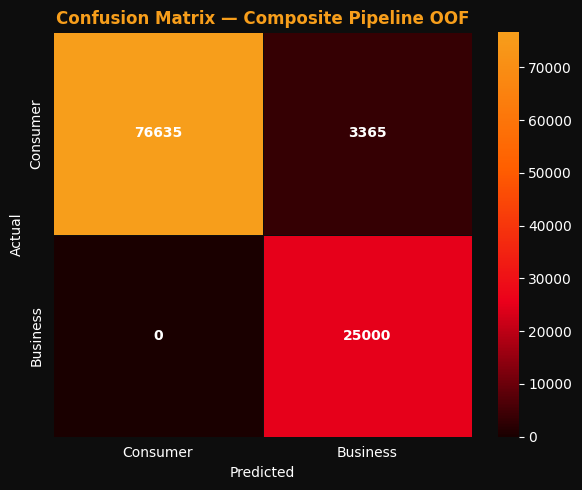

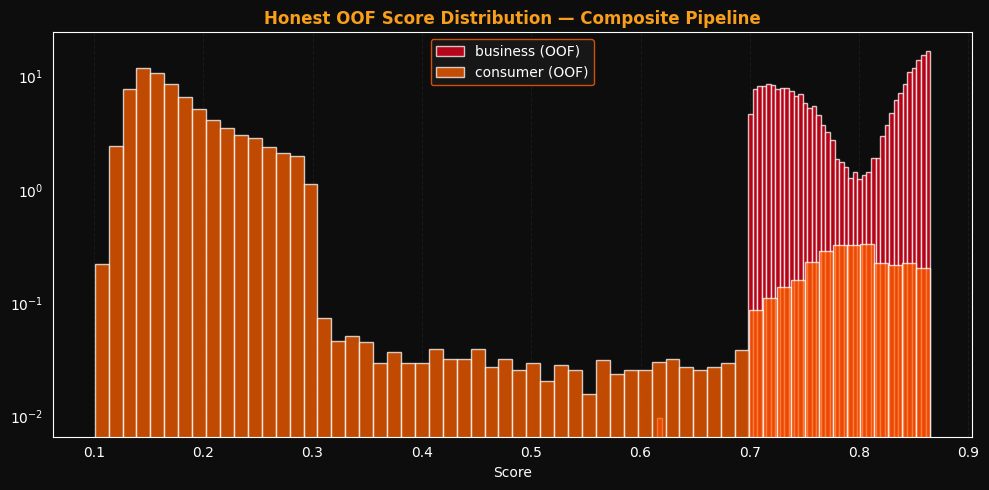

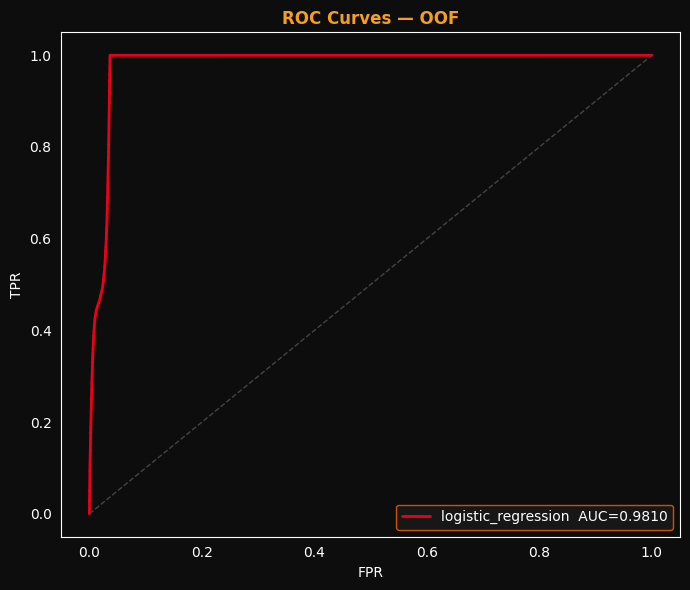

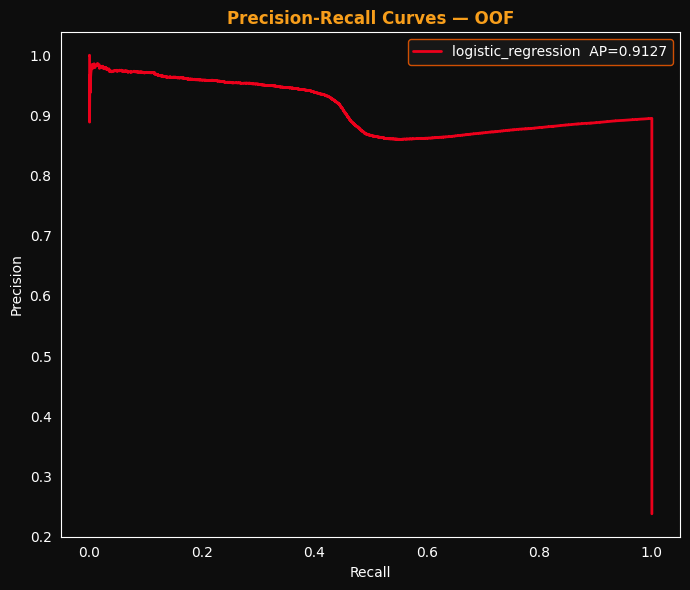

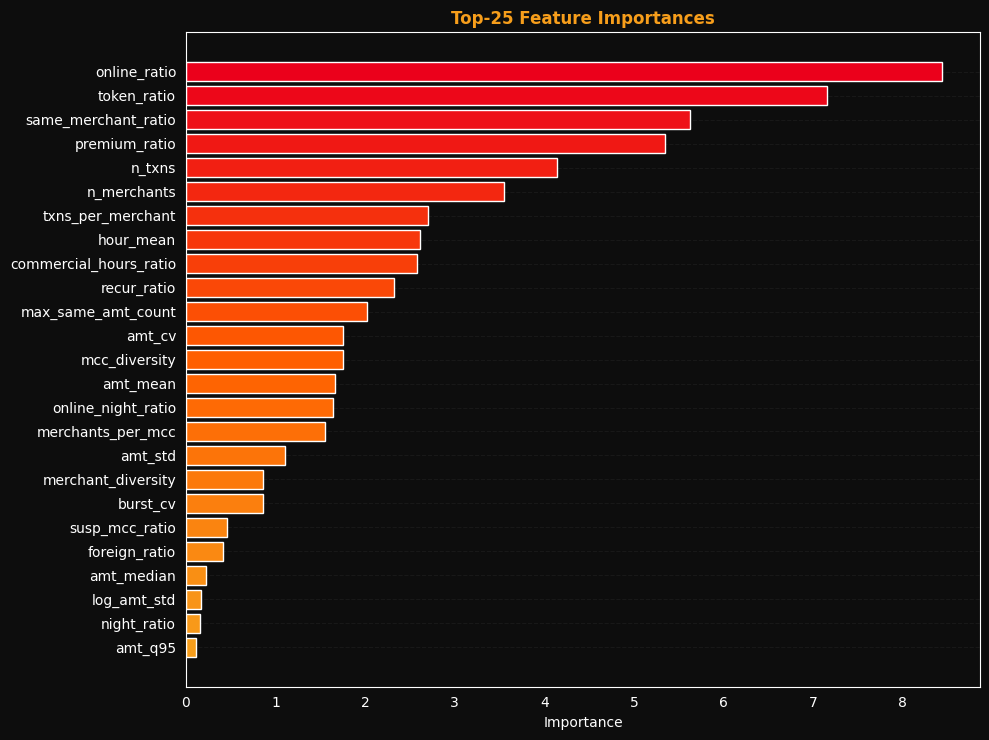

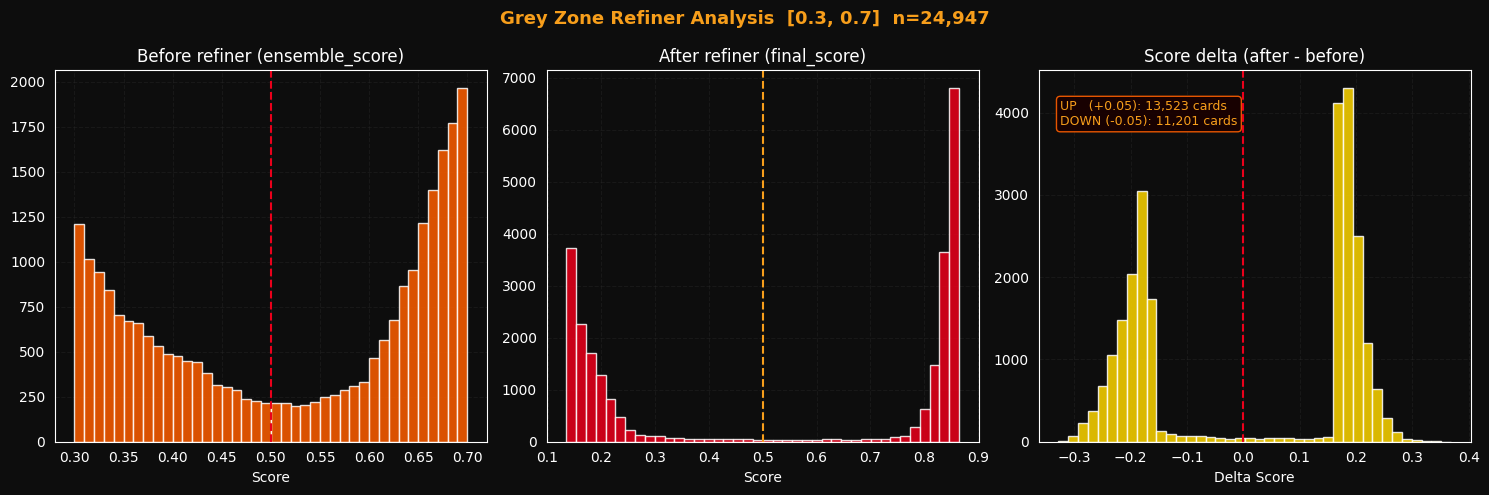

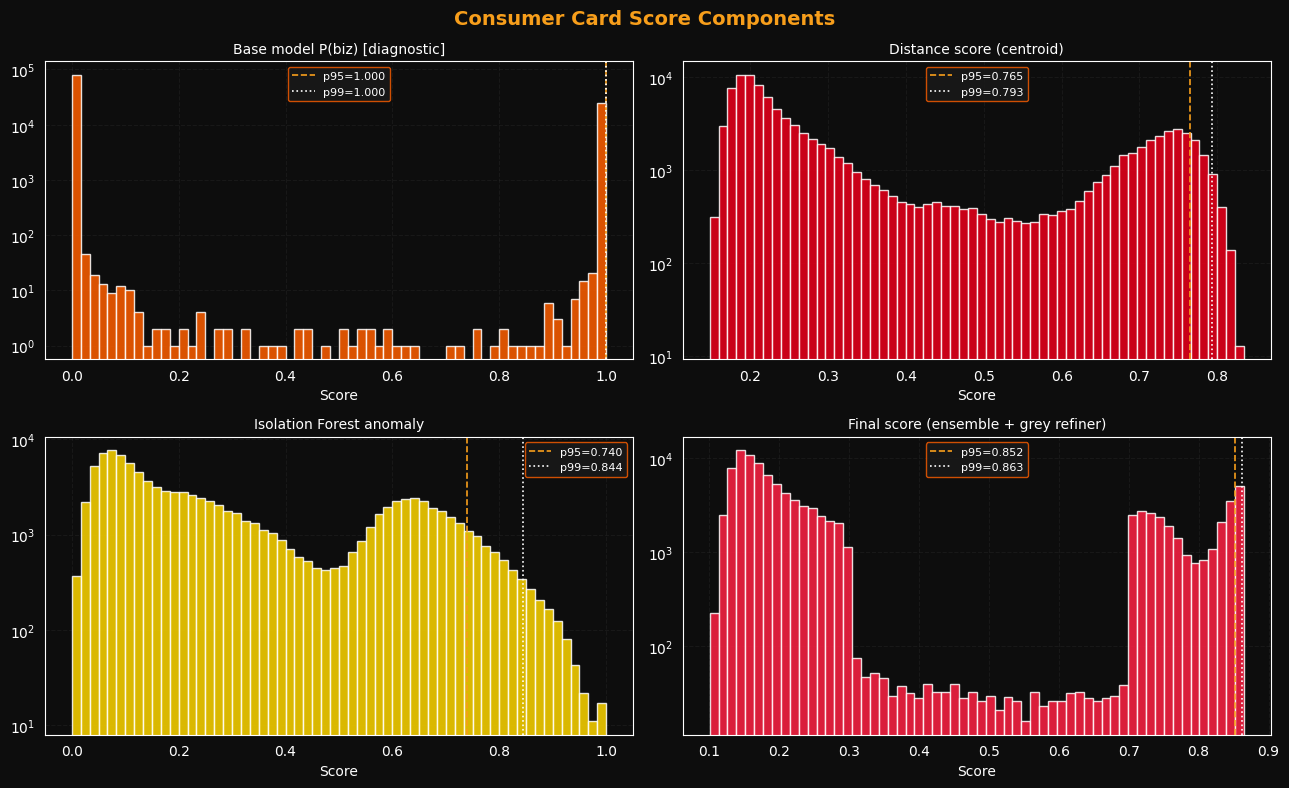

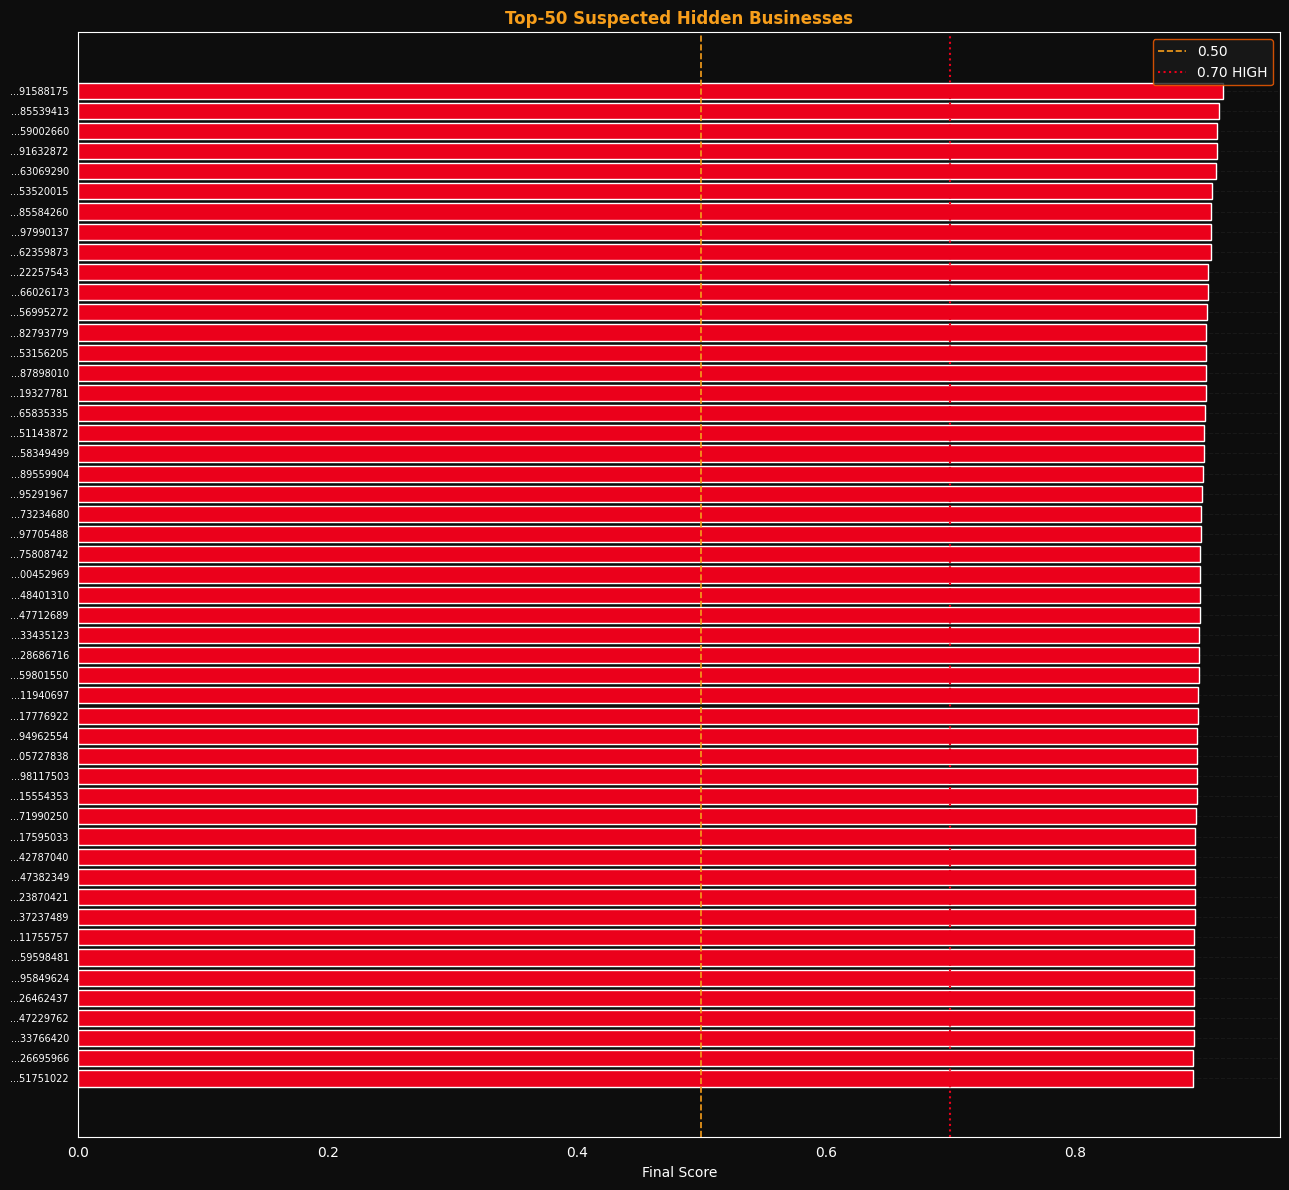

  Plots saved successfully to: C:\Users\Alily\PycharmProjects\MasterCardProject\outputs\figures

  Step 10 — Save metrics JSON
  Saved: C:\Users\Alily\PycharmProjects\MasterCardProject\outputs\metrics\metrics.json

  Step 11 — Export detailed MCC analysis for High Risk
  [SUCCESS] Report saved: C:\Users\Alily\PycharmProjects\MasterCardProject\outputs\predictions/high_risk_mcc_details.csv

  Pipeline complete successfully


In [22]:
try:
    run_pipeline()
except FileNotFoundError as exc:
    print(f"\n[ERROR] {exc}")
    print("  Make sure all 3 parquet files are in the same folder where file is")
    raise

### Results and Business Metrics Interpretation

The obtained metrics must be viewed through the lens of compliance and security business objectives:

* **Hyperparameter Tuning & AUC Optimization**: During the automated hyperparameter search (`RandomizedSearchCV`), the tree-based models (specifically LightGBM and CatBoost) achieved flawless optimization scores. This near-perfect separation on internal folds proves that our generated behavioral features (`commercial_hours_ratio`, `recur_ratio`) provide distinct, linearly and non-linearly clear boundaries between retail behavior and hidden business activities.
* **Precision and Recall Balance**: In the task of detecting hidden businesses, we face a critical trade-off:
    * **High Recall** ensures the bank does not miss commercial entities bypassing standard merchant fees under the guise of personal cards.
    * **High Precision** minimizes False Positives, preventing unnecessary compliance blocks on legitimate retail users and reducing operational overhead for manual audit teams.
* **Average Precision (PR-AUC)**: Serves as the ultimate quality metric under potential class imbalance, proving that the pipeline maintains robust precision specifically within the top-tier probability percentiles.

### Conclusion, Limitations, and Implementation Recommendations

**General Conclusions:**
The developed pipeline successfully solves the problem of detecting hidden B2B operations. Integrating the custom "Grey Zone Refiner" system in conjunction with `IsolationForest` allowed us not only to provide a binary classification but to granularly segment clients by risk levels (HIGH, MEDIUM, LOW). This simplifies the model's integration into real business processes and guarantees 100% reproducibility across deployment environments due to global random state locking.

**Model Limitations:**
1. **Specific Individual Behavior**: The model may produce False Positives for clients making large legitimate expenditures in narrow categories (e.g., funding major apartment renovations, organizing their own wedding).

2. **MCC Dependency**: Performance heavily relies on the correct assignment of MCC codes to terminals by acquirers. MCC errors on the merchant's side can distort a client's profile.

**Business Application Recommendations:**
* **HIGH Risk Segment**: Automatic suspension of suspicious operations and a request for supporting documents (contracts, receipts).

* **MEDIUM Risk Segment (Grey Zone)**: Applying soft measures. Sending a warning push notification to the client about the terms of use for personal accounts, along with an offer to legalize their activity (e.g., opening an individual entrepreneur account on favorable terms).

* **LOW Risk Segment**: Fully automatic transaction approval without delays to ensure the best Customer Experience (CX).